In [1]:
from dataset_augmented_simulation import AugmentedSimulationDataset
import numpy as np
import matplotlib.pyplot as plt
def test_augmented_dataset_visualization(data_length, scenarios, data_folder, num_samples=5):
    """
    Visualize random samples from AugmentedSimulationDataset.
    Plots the scenario map and overlays the observed track.
    """
    dataset = AugmentedSimulationDataset(
        data_length=data_length,
        scenarios=scenarios,
        data_folder=data_folder,
        load_scenario_map=True
    )
    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        sample = dataset[idx]
        scen_map = sample['scen_map']
        track = sample['observed_data']
        mask = sample['observed_mask']

        plt.figure(figsize=(5, 5))
        plt.imshow(scen_map.astype(np.uint8))
        # mask is (T, 2) for (x, y); valid if both True
        valid_points = track[(mask[:, 0] & mask[:, 1])]
        if valid_points.shape[0] > 0:
            plt.plot(valid_points[:, 0], valid_points[:, 1], marker='o', color='red')
        plt.title(f'Sample {i}')
        plt.axis('off')
        plt.show()

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from dataset_simulation import Simulation_Dataset

def visualize_simulation_dataset(data_length, scenarios, data_folder, mode="train", num_samples=5):
    """
    Visualize tracks on scenario map, restoring zero-based offset and flipping Y for correct alignment.
    """
    dataset = Simulation_Dataset(
        data_length=data_length,
        scenarios=scenarios,
        data_folder=data_folder,
        mode=mode,
        load_scenario_map=True,
        zero_based_position=True
    )

    for i in range(num_samples):
        index = np.random.randint(len(dataset))
        sample = dataset[index]
        scenario_index, scenario_name = dataset.get_index(index)

        scen_map = sample['scen_map']
        track = sample['observed_data']
        mask = sample['observed_mask']
        scale = sample.get('scen_map_scale', np.array([1.0, 1.0]))

        # Restore original origin (undo zero-based offset)
        origin_offset = dataset.origin_position[scenario_name]
        #print(f"Visualizing scenario {scenario_name} at index {index} with origin offset {origin_offset}")
        #track = track + origin_offset  # shape (T, 2)

        # Scale
        track_scaled = track * scale

        # Flip Y
        map_height = scen_map.shape[0]
        track_scaled[:, 1] = map_height - track_scaled[:, 1]

        # Plot
        plt.figure(figsize=(5, 5))
        plt.imshow(scen_map.astype(np.uint8))
        valid_points = track_scaled[(mask[:, 0] & mask[:, 1])]
        if valid_points.shape[0] > 0:
            plt.plot(valid_points[:, 0], valid_points[:, 1], marker='o', color='red', linewidth=1, markersize=4)
        plt.title(f"Scenario {scenario_name} | Sample {i}")
        plt.axis('off')
        plt.show()

In [ ]:
data_length = 200
scenairos = None
data_folder = None
visualize_simulation_dataset(data_length, scenairos, data_folder, mode="train", num_samples=15)
#test_augmented_dataset_visualization(data_length, scenairos, data_folder)

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from dataset_augmented_simulation import AugmentedSimulationDataset

def test_augmented_dataset_visualization(data_length, scenarios, data_folder, num_samples=5, resize_to=(128, 128)):
    """
    Visualize random samples from AugmentedSimulationDataset.
    - Shows the scenario map and overlays the scaled, flipped track.
    - Applies Y-flip to match image coordinates.
    
    Args:
        data_length (int): Number of time steps in each track.
        scenarios (list of str): Scenario names to include.
        data_folder (str): Path to the simulation dataset root.
        num_samples (int): How many random samples to visualize.
        resize_to (tuple): Shape to which maps are resized.
    """
    dataset = AugmentedSimulationDataset(
        data_length=data_length,
        scenarios=scenarios,
        data_folder=data_folder,
        load_scenario_map=True,
        resize_to=resize_to
    )

    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        sample = dataset[idx]
        scen_map = sample['scen_map']  # (H, W, 3)
        track = sample['observed_data']  # (T, 2)
        mask = sample['observed_mask']  # (T, 2)

        # Flip Y-axis to align with image coordinates
        track = track.copy()
        map_height = scen_map.shape[0]
        track[:, 1] = map_height - track[:, 1]

        # Filter valid track points (both x and y must be valid)
        valid_points = track[(mask[:, 0] & mask[:, 1])]

        # Plot
        plt.figure(figsize=(5, 5))
        plt.imshow(scen_map.astype(np.uint8))
        if valid_points.shape[0] > 0:
            plt.plot(valid_points[:, 0], valid_points[:, 1], marker='o', color='red', linewidth=1, markersize=4)
        plt.title(f'Sample {i}')
        plt.axis('off')
        plt.show()

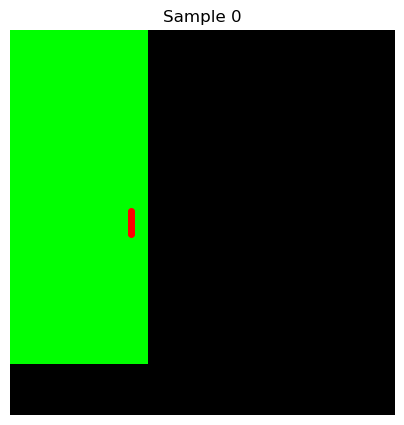

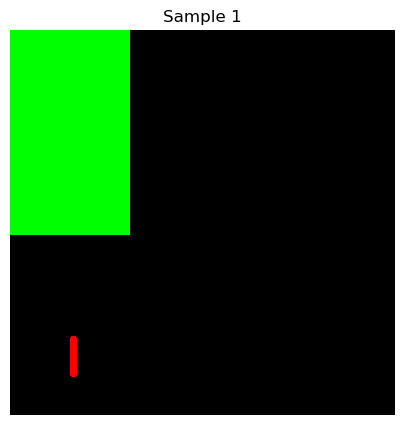

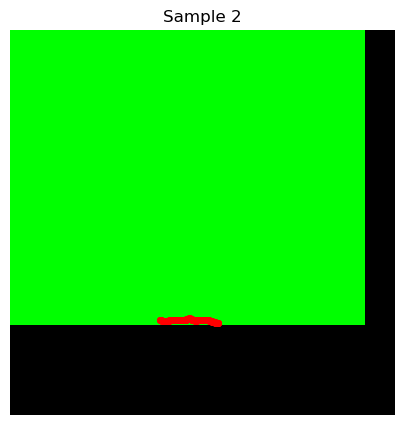

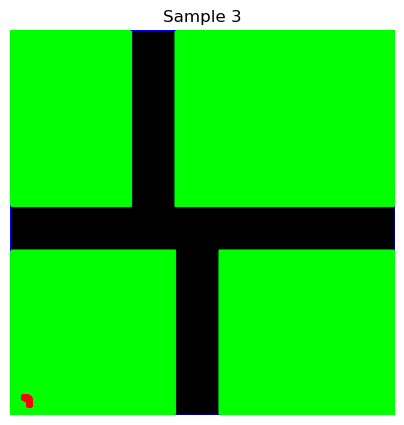

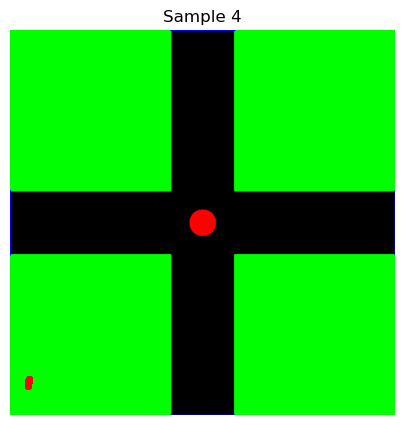

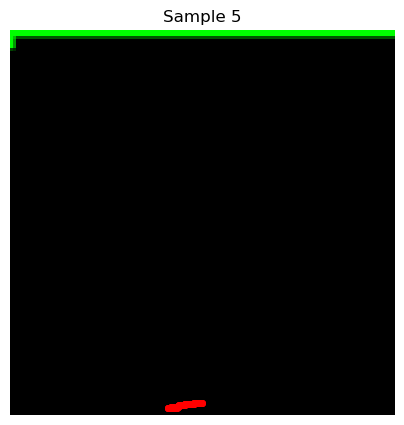

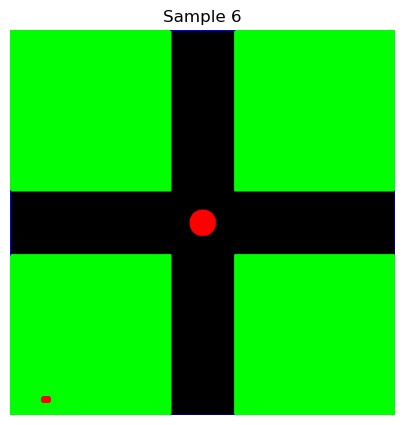

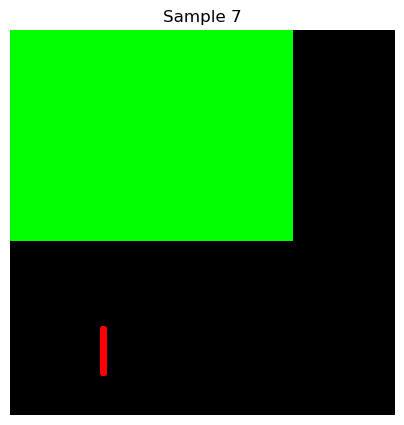

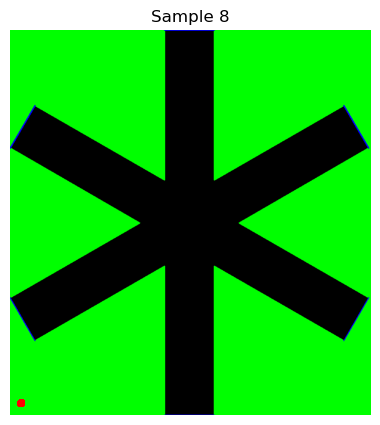

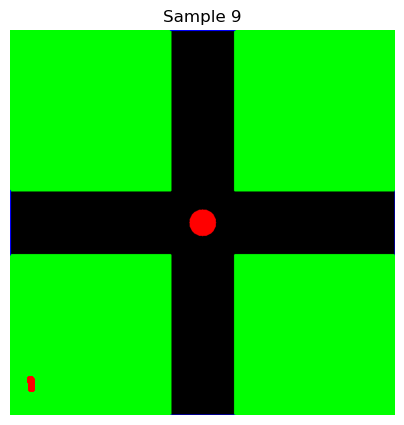

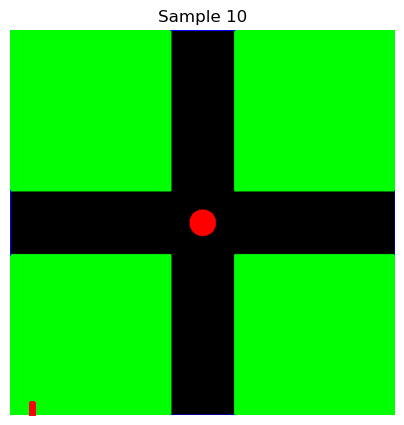

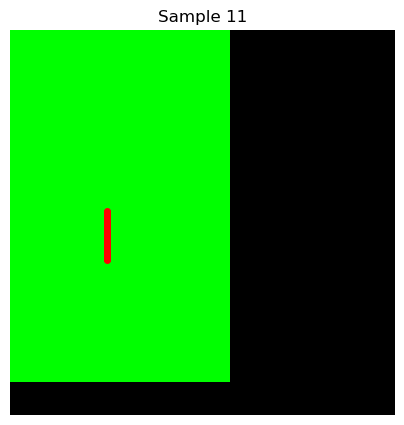

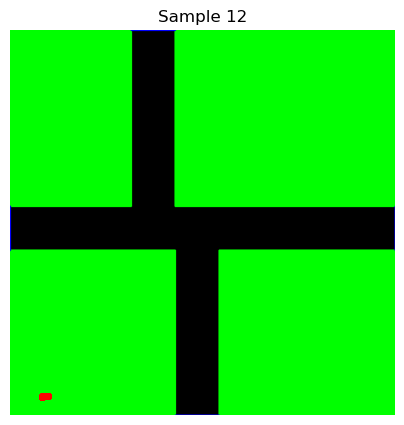

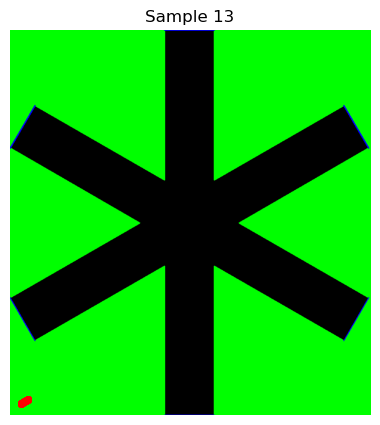

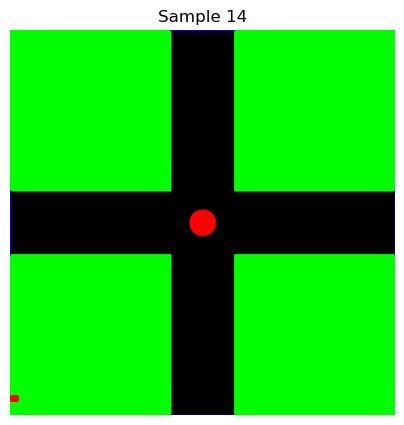

In [6]:
data_length = 200
scenairos = None
data_folder = None
test_augmented_dataset_visualization(data_length, scenairos, data_folder, num_samples=15)